In [18]:
# correlation between interest rates and the housing market
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred

# Get the current price of all S&P 500 stocks
from pandas_datareader import data as pdr
import yfinance as yf

FRED_API_KEY = "612c90fb30af12767bbcaf9513bac5ed"
fred = Fred(api_key=FRED_API_KEY)


In [19]:
def plot_it(data: pd.Series, title: str, figsize: tuple[int, int] = (15, 5)) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(data)
    ax.grid(True, which="both")
    plt.title(title)


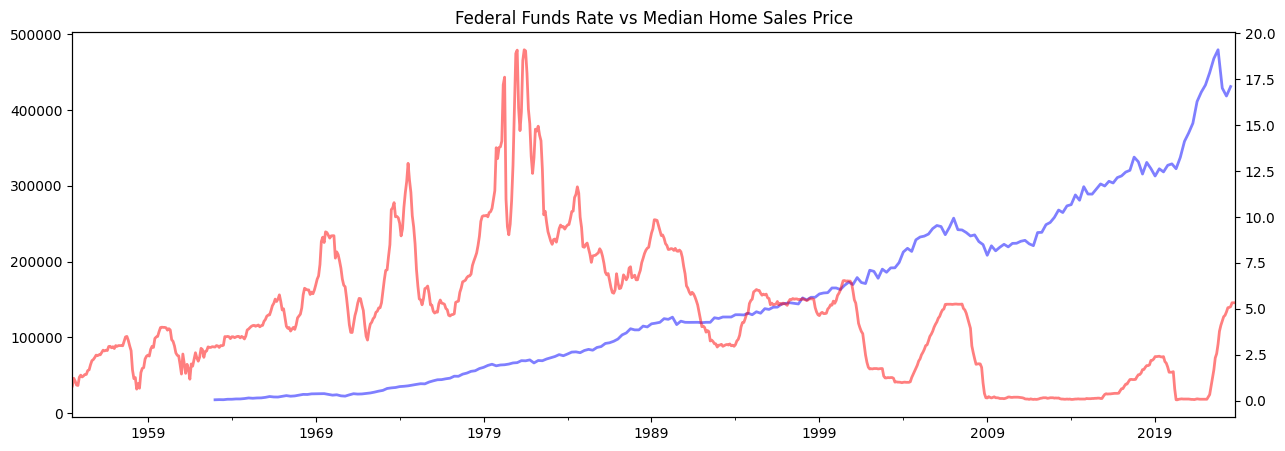

In [20]:
df_fed_funds = fred.get_series("FEDFUNDS").dropna()
df_home_prices = fred.get_series("MSPUS").dropna()

fig, ax = plt.subplots(figsize=(15, 5))
df_fed_funds.plot(
    ax=ax,
    secondary_y=True,
    color="red",
    alpha=0.5,
    linewidth=2,
    title="Federal Funds Rate vs Median Home Sales Price",
)
df_home_prices.plot(ax=ax, color="blue", alpha=0.5, linewidth=2)
plt.show()


In [21]:
# Correlation Coefficient = 0.6: A moderate positive relationship.
print(
    f"Federal Funds Rate correlation with Median Home Sales Price: {df_fed_funds.corr(df_home_prices, method='pearson')}"
)


Federal Funds Rate correlation with Median Home Sales Price: -0.6048362697906242


In [22]:
df_sp500 = fred.get_series("SP500")


In [23]:
df_sp500.corr(df_fed_funds, method="pearson")


0.38942558194457166

In [24]:
# Spikes in the cost of borrowing, and in energy prices, have been forerunners of recession in the past

# Market Yield on U.S. Treasury Securities at 10-Year Constant Maturity, Quoted on an Investment Basis (DGS10)
df_treasury = fred.get_series("DGS10").dropna()

# Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
df_oil = fred.get_series("DCOILWTICO").dropna()
print(
    f"Correlation between treasury yields and crude oil prices: {df_treasury.corr(df_oil, method='pearson')}"
)


Correlation between treasury yields and crude oil prices: -0.6684342051585916
